# Patient Readmission Risk Stratification




In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split    
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score,
                              precision_score, recall_score, accuracy_score,
                              confusion_matrix, classification_report, roc_curve)

sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', 60)
RANDOM_STATE = 42


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split    
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score,
                              precision_score, recall_score, accuracy_score,
                              confusion_matrix, classification_report, roc_curve)

sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', 60)
RANDOM_STATE = 42


In [3]:
import sys
print(sys.executable)

/usr/bin/python3


## 1. Load data

In [4]:
df = pd.read_csv('diabetic_data.csv')
ids_map = pd.read_csv('IDS_mapping.csv')
print("Shape:", df.shape)
df.head()


Shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [5]:

df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


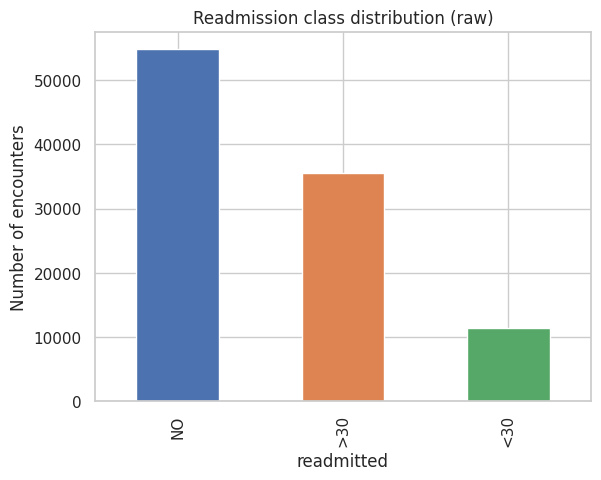

weight               96.858479
max_glu_serum        94.746772
A1Cresult            83.277322
medical_specialty    49.082208
payer_code           39.557416
race                  2.233555
diag_3                1.398306
diag_2                0.351787
diag_1                0.020636
dtype: float64


In [6]:
df['readmitted'].value_counts().plot(kind='bar', color=['#4C72B0', '#DD8452', '#55A868'])
plt.title('Readmission class distribution (raw)')
plt.ylabel('Number of encounters')
plt.show()

missing_pct = (df.replace('?', np.nan).isna().mean() * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]
print(missing_pct)


## 2. Cleaning

In [7]:
df = df.replace('?', np.nan)

EXPIRE_HOSPICE = [11, 13, 14, 19, 20, 21]
df = df[~df['discharge_disposition_id'].isin(EXPIRE_HOSPICE)].copy()

df = df.sort_values('encounter_id').drop_duplicates(subset='patient_nbr', keep='first')

df = df.drop(columns=['weight', 'payer_code'])

top_spec = df['medical_specialty'].value_counts().nlargest(10).index
df['medical_specialty'] = df['medical_specialty'].where(df['medical_specialty'].isin(top_spec), 'Other')
df['medical_specialty'] = df['medical_specialty'].fillna('Missing')
# 'race' dropped: not used as a predictive feature (avoids encoding a protected attribute into the model)
df = df.drop(columns=['race'])

print("Shape after cleaning:", df.shape)


Shape after cleaning: (69990, 47)


## 3. Feature extraction

### 3.1 Age


In [8]:
age_map = {f'[{i}-{i+10})': i + 5 for i in range(0, 100, 10)}
df['age_mid'] = df['age'].map(age_map)


### 3.2 High-risk disease mapping (ICD-9 → clinical category)


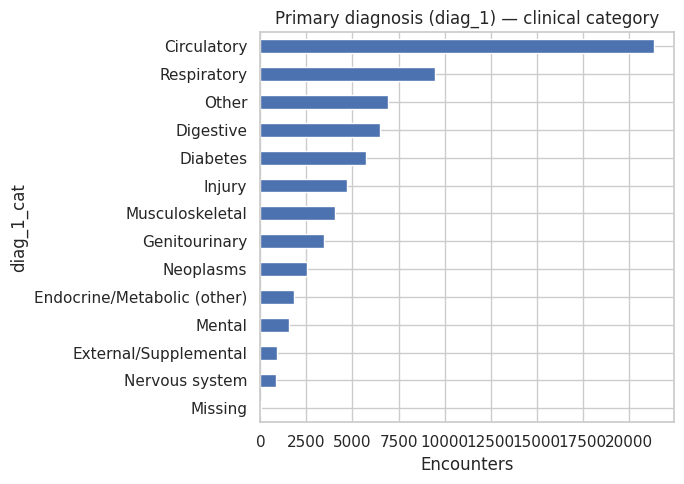

In [9]:
def icd9_category(code):
    if pd.isna(code):
        return 'Missing'
    code = str(code)
    if code.startswith('V') or code.startswith('E'):
        return 'External/Supplemental'
    try:
        val = float(code)
    except ValueError:
        return 'Other'
    if 390 <= val <= 459 or val == 785:
        return 'Circulatory'
    if 460 <= val <= 519 or val == 786:
        return 'Respiratory'
    if 520 <= val <= 579 or val == 787:
        return 'Digestive'
    if 250 <= val < 251:
        return 'Diabetes'
    if 800 <= val <= 999:
        return 'Injury'
    if 710 <= val <= 739:
        return 'Musculoskeletal'
    if 580 <= val <= 629 or val == 788:
        return 'Genitourinary'
    if 140 <= val <= 239:
        return 'Neoplasms'
    if 240 <= val <= 279:
        return 'Endocrine/Metabolic (other)'
    if 290 <= val <= 319:
        return 'Mental'
    if 320 <= val <= 389:
        return 'Nervous system'
    return 'Other'

HIGH_RISK_CATEGORIES = {'Circulatory', 'Diabetes', 'Respiratory', 'Genitourinary', 'Neoplasms'}

for c in ['diag_1', 'diag_2', 'diag_3']:
    df[c + '_cat'] = df[c].apply(icd9_category)

df['n_high_risk_dx'] = df[['diag_1_cat', 'diag_2_cat', 'diag_3_cat']].apply(
    lambda row: sum(v in HIGH_RISK_CATEGORIES for v in row), axis=1)

for cat, flag in [('Circulatory', 'has_circulatory_dx'), ('Diabetes', 'has_diabetes_dx'),
                   ('Respiratory', 'has_respiratory_dx'), ('Genitourinary', 'has_genitourinary_dx'),
                   ('Neoplasms', 'has_neoplasm_dx')]:
    df[flag] = df[['diag_1_cat', 'diag_2_cat', 'diag_3_cat']].eq(cat).any(axis=1).astype(int)

df['high_risk_disease_flag'] = (df['n_high_risk_dx'] > 0).astype(int)

df['diag_1_cat'].value_counts().plot(kind='barh', figsize=(7, 5), color='#4C72B0')
plt.title('Primary diagnosis (diag_1) — clinical category')
plt.xlabel('Encounters')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


### 3.3 Medication features


In [10]:
med_cols = ['metformin','repaglinide','nateglinide','chlorpropamide','glimepiride',
            'acetohexamide','glipizide','glyburide','tolbutamide','pioglitazone',
            'rosiglitazone','acarbose','miglitol','troglitazone','tolazamide',
            'examide','citoglipton','insulin','glyburide-metformin','glipizide-metformin',
            'glimepiride-pioglitazone','metformin-rosiglitazone','metformin-pioglitazone']

df['num_meds_active'] = (df[med_cols] != 'No').sum(axis=1)
df['num_meds_changed'] = (df[med_cols].isin(['Up', 'Down'])).sum(axis=1)


### 3.4 Target variable


In [11]:
df['readmit_30d'] = (df['readmitted'] == '<30').astype(int)
df['readmit_30d'].value_counts(normalize=True).rename('proportion')


readmit_30d
0    0.910201
1    0.089799
Name: proportion, dtype: float64

## 4. Encoding & train/test split

- Categorical features → one-hot encoding
- Numeric features → standard scaling
- Stratified 80/20 split on the target to preserve class balance
- Class imbalance (~9% positive) handled via `class_weight='balanced'` (Logistic Regression, Random Forest) and `scale_pos_weight` (XGBoost) rather than resampling, to keep the test set's real-world prevalence intact for evaluation.

In [12]:
# 'race' intentionally excluded (protected attribute).
# encounter_id / patient_nbr are identifiers only -- kept in `ids` for tracking, never used as model features.
categorical_cols = ['gender', 'admission_type_id', 'discharge_disposition_id',
                     'admission_source_id', 'medical_specialty', 'max_glu_serum', 'A1Cresult',
                     'change', 'diabetesMed', 'diag_1_cat', 'diag_2_cat', 'diag_3_cat']

numeric_cols = ['age_mid', 'time_in_hospital', 'num_lab_procedures', 'num_procedures',
                'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient',
                'number_diagnoses', 'n_high_risk_dx', 'has_circulatory_dx', 'has_diabetes_dx',
                'has_respiratory_dx', 'has_genitourinary_dx', 'has_neoplasm_dx',
                'high_risk_disease_flag', 'num_meds_active', 'num_meds_changed']

for c in categorical_cols:
    df[c] = df[c].astype(str)

X = df[categorical_cols + numeric_cols]
y = df['readmit_30d']
ids = df[['encounter_id', 'patient_nbr']]

X_train, X_test, y_train, y_test, id_train, id_test = train_test_split(
    X, y, ids, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

print("Train:", X_train.shape, " Test:", X_test.shape)

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])
     

Train: (55992, 30)  Test: (13998, 30)


## 5. Model training

Three complementary algorithms:
- **Logistic Regression** — interpretable linear baseline
- **Random Forest** — non-linear, robust to feature scaling, gives feature importance
- **XGBoost** — gradient-boosted trees, typically strongest tabular performance

In [13]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=300, max_depth=8, class_weight='balanced',
                                             random_state=RANDOM_STATE, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                              scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
                              eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1)
}

fitted = {}
for name, clf in models.items():
    pipe = Pipeline([('pre', preprocessor), ('clf', clf)])
    pipe.fit(X_train, y_train)
    fitted[name] = pipe
    print(f"{name} trained.")


Logistic Regression trained.


Random Forest trained.


XGBoost trained.


## 6. Evaluation



In [14]:
results = {}
for name, pipe in fitted.items():
    proba = pipe.predict_proba(X_test)[:, 1]
    pred = (proba >= 0.5).astype(int)
    results[name] = {
        'roc_auc': roc_auc_score(y_test, proba),
        'pr_auc': average_precision_score(y_test, proba),
        'f1': f1_score(y_test, pred),
        'precision': precision_score(y_test, pred),
        'recall': recall_score(y_test, pred),
        'accuracy': accuracy_score(y_test, pred),
    }

results_df = pd.DataFrame(results).T.round(4)
results_df




,roc_auc,pr_auc,f1,precision,recall,accuracy
Logistic Regression,0.6506,0.1715,0.2246,0.1418,0.5394,0.6656
Random Forest,0.6519,0.1728,0.2237,0.1425,0.5195,0.6762
XGBoost,0.6544,0.1847,0.2239,0.1410,0.5434,0.6617


In [15]:
for model, metrics in results.items():
    print(f"{model}: {metrics['accuracy'] * 100:.2f}%")

Logistic Regression: 66.56%
Random Forest: 67.62%
XGBoost: 66.17%


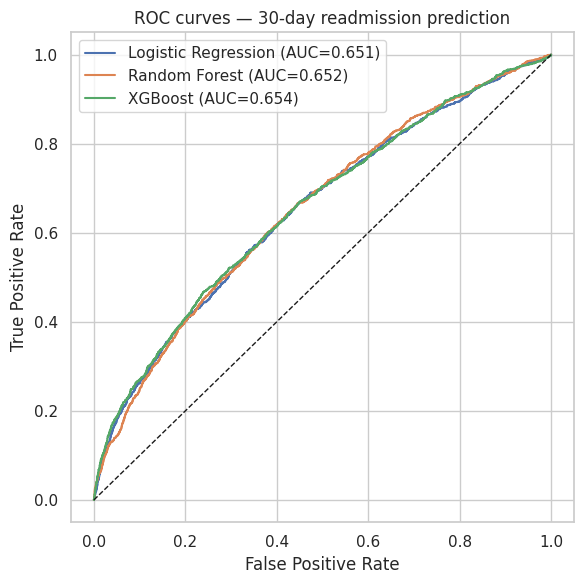

In [16]:
plt.figure(figsize=(6, 6))
for name, pipe in fitted.items():
    proba = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={results[name]['roc_auc']:.3f})")
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curves — 30-day readmission prediction')
plt.legend()
plt.tight_layout()
plt.show()


Best model by ROC-AUC: XGBoost


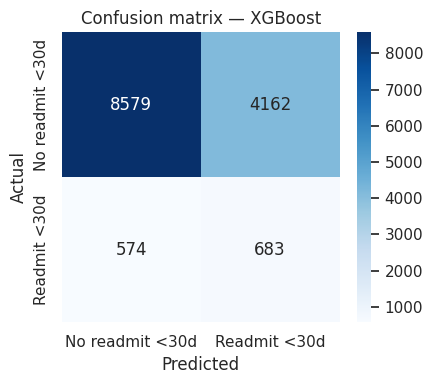

                 precision    recall  f1-score   support

No readmit <30d       0.94      0.67      0.78     12741
   Readmit <30d       0.14      0.54      0.22      1257

       accuracy                           0.66     13998
      macro avg       0.54      0.61      0.50     13998
   weighted avg       0.87      0.66      0.73     13998



In [17]:
best_name = max(results, key=lambda n: results[n]['roc_auc'])
print("Best model by ROC-AUC:", best_name)
best_pipe = fitted[best_name]
proba_test = best_pipe.predict_proba(X_test)[:, 1]
pred_test = (proba_test >= 0.5).astype(int)

cm = confusion_matrix(y_test, pred_test)
plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No readmit <30d', 'Readmit <30d'],
            yticklabels=['No readmit <30d', 'Readmit <30d'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title(f'Confusion matrix — {best_name}')
plt.tight_layout()
plt.show()

print(classification_report(y_test, pred_test, target_names=['No readmit <30d', 'Readmit <30d']))


ROC-AUC: 0.6544
PR-AUC: 0.1847
Accuracy: 66.17%
Precision: 14.10%
Recall: 54.34%
F1-score: 22.39%

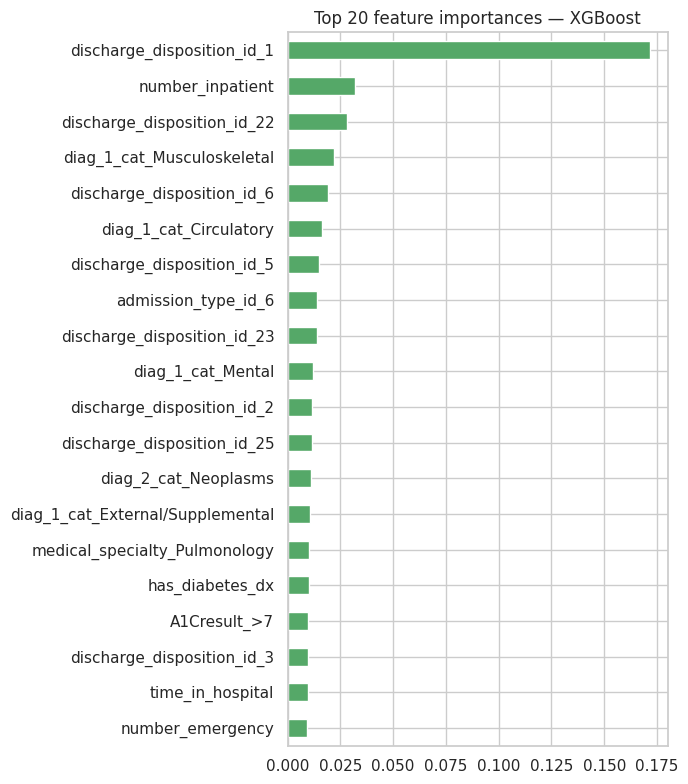

In [18]:
if best_name in ('Random Forest', 'XGBoost'):
    feature_names = (numeric_cols +
                      list(best_pipe.named_steps['pre'].named_transformers_['cat']
                           .get_feature_names_out(categorical_cols)))
    importances = best_pipe.named_steps['clf'].feature_importances_
    fi = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(20)
    fi.iloc[::-1].plot(kind='barh', figsize=(7, 8), color='#55A868')
    plt.title(f'Top 20 feature importances — {best_name}')
    plt.tight_layout()
    plt.show()


## 7. Patient risk stratification



| Predicted probability | Risk band |
|---|---|
| < 0.33 | **Low** |
| 0.33 – 0.66 | **Medium** |
| > 0.66 | **High** |



In [19]:
out = id_test.copy()
out['actual_readmit_30d'] = y_test.values
out['predicted_probability'] = proba_test
out['risk_category'] = pd.cut(out['predicted_probability'], bins=[-0.01, 0.33, 0.66, 1.0],
                               labels=['Low', 'Medium', 'High'])

# Add the high-risk-disease context back in for clinical review
disease_cols = ['n_high_risk_dx', 'has_circulatory_dx', 'has_diabetes_dx',
                 'has_respiratory_dx', 'has_genitourinary_dx', 'has_neoplasm_dx']
out = out.join(df.loc[X_test.index, disease_cols])

validation = out.groupby('risk_category', observed=True)['actual_readmit_30d'].agg(['mean', 'count'])
validation.columns = ['actual_readmit_rate', 'n_patients']
validation


,actual_readmit_rate,n_patients
risk_category,,
Low,0.044331,2346
Medium,0.085382,10822
High,0.275904,830


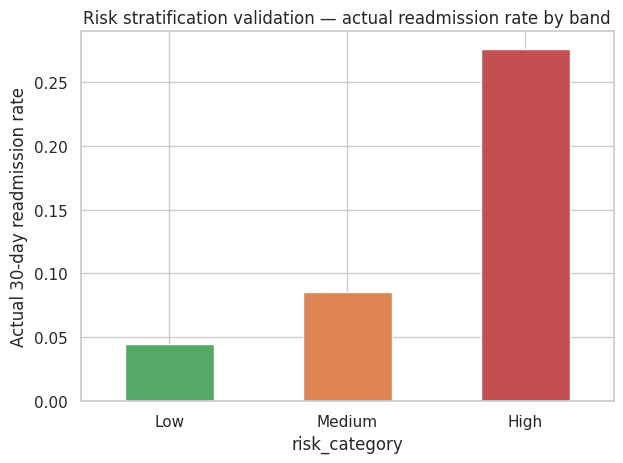

In [20]:
ax = validation['actual_readmit_rate'].plot(kind='bar', color=['#55A868', '#DD8452', '#C44E52'])
plt.ylabel('Actual 30-day readmission rate')
plt.title('Risk stratification validation — actual readmission rate by band')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 8. Hospital Resource Planning (Novelty)

A risk score alone doesn't tell an administrator how many beds, case managers, or follow-up slots to plan for. This section turns the model's patient-level `predicted_probability` and `risk_category` into an operational resource plan:

1. **Resource intensity profile** — how costly (length of stay, procedures, meds) each risk band typically is.
2. **Intervention policy** — what discharge intervention and staffing ratio each risk band gets.
3. **Expected bed-day burden** — for each patient, `predicted_probability * time_in_hospital` estimates the bed-days the hospital should reserve capacity for if that patient bounces back, using their own stay as a proxy for a likely readmission stay. Summed by band/department, this gives a forward-looking capacity number instead of just a headcount.
4. **Department-level allocation** — the same breakdown by `medical_specialty`, so planning can be targeted at the units carrying the most risk.

In [21]:
RESOURCE_FEATURES = ['medical_specialty', 'admission_type_id', 'time_in_hospital',
                      'num_procedures', 'num_medications', 'num_lab_procedures']

planning_df = out.join(df.loc[X_test.index, RESOURCE_FEATURES])
planning_df.head()


,encounter_id,patient_nbr,actual_readmit_30d,predicted_probability,risk_category,n_high_risk_dx,has_circulatory_dx,has_diabetes_dx,has_respiratory_dx,has_genitourinary_dx,has_neoplasm_dx,medical_specialty,admission_type_id,time_in_hospital,num_procedures,num_medications,num_lab_procedures
29542,96431664,8045829,0,0.308408,Low,3,1,1,1,0,0,InternalMedicine,2,2,2,10,45
47637,146293770,98619903,0,0.419749,Medium,3,1,0,0,0,0,Cardiology,2,2,5,9,33
41683,128884314,99847818,0,0.565594,Medium,2,0,1,1,0,0,Emergency/Trauma,1,10,0,13,1
20277,71578422,3322665,0,0.449478,Medium,1,0,1,0,0,0,InternalMedicine,1,8,4,14,40
93084,330778598,32216409,0,0.386652,Medium,1,1,0,0,0,0,Radiologist,3,2,1,13,1


### 8.1 Resource intensity profile by risk band

In [22]:
intensity_profile = planning_df.groupby('risk_category', observed=True).agg(
    n_patients=('encounter_id', 'count'),
    avg_time_in_hospital=('time_in_hospital', 'mean'),
    avg_num_procedures=('num_procedures', 'mean'),
    avg_num_medications=('num_medications', 'mean'),
    avg_num_lab_procedures=('num_lab_procedures', 'mean'),
    predicted_readmit_rate=('predicted_probability', 'mean'),
).round(2)
intensity_profile


,n_patients,avg_time_in_hospital,avg_num_procedures,avg_num_medications,avg_num_lab_procedures,predicted_readmit_rate
risk_category,,,,,,
Low,2346,2.81,1.20,12.64,35.13,0.27
Medium,10822,4.48,1.51,16.08,44.15,0.47
High,830,5.59,1.30,18.11,47.58,0.73


### 8.2 Intervention policy & staffing requirement

**Fixed a unit-mismatch bug here.** The original version summed `predicted_probability * time_in_hospital` across the whole test cohort and called that "bed-days" -- but a raw sum over an unspecified number of patients has no time period attached, so it can't be compared to a snapshot count of beds or staff on hand. The model predicts **30-day** readmission risk, so we treat this cohort as representing that many patients discharged over a `PLANNING_HORIZON_DAYS`-day window (30 days by default -- matches the prediction target; treat it as an explicit, adjustable assumption, not a fact the data tells us). That lets us convert:
- cumulative bed-days -> **average beds occupied per day** (comparable to a beds-available count)
- total patient headcount -> **concurrent caseload** via Little's Law (arrival rate x how long each patient stays in the follow-up program), which is what a staffing ratio like "20 patients per case manager" actually means in practice.

In [23]:
import math

# How many days this test cohort is assumed to represent. The model predicts 30-day readmission risk,
# so 30 is the natural default -- but this is an explicit assumption, not something the data tells us.
# Change it if you know your real discharge cohort spans a different window.
PLANNING_HORIZON_DAYS = 30

# Rule-based discharge intervention policy. 'concurrent_capacity_per_fte' is how many ACTIVE cases one
# staff member can carry at once (not a lifetime headcount).
INTERVENTION_POLICY = {
    'High':   {'intervention': 'Case-manager led transition-of-care + home health referral',
               'follow_up_within_days': 2,  'staff_role': 'Case manager',    'concurrent_capacity_per_fte': 20},
    'Medium': {'intervention': 'Structured follow-up phone call + pharmacist medication review',
               'follow_up_within_days': 7,  'staff_role': 'Follow-up nurse', 'concurrent_capacity_per_fte': 60},
    'Low':    {'intervention': 'Standard discharge instructions',
               'follow_up_within_days': 30, 'staff_role': 'None (standard discharge)', 'concurrent_capacity_per_fte': None},
}

resource_plan = intensity_profile.copy()

expected_bed_days = planning_df.groupby('risk_category', observed=True).apply(
    lambda g: (g['predicted_probability'] * g['time_in_hospital']).sum())
resource_plan['expected_bed_days'] = expected_bed_days.round(1)
# The comparable-to-capacity number: cumulative bed-days spread over the planning horizon.
resource_plan['avg_daily_beds_needed'] = (expected_bed_days / PLANNING_HORIZON_DAYS).round(2)

resource_plan['intervention'] = [INTERVENTION_POLICY[b]['intervention'] for b in resource_plan.index]
resource_plan['follow_up_within_days'] = [INTERVENTION_POLICY[b]['follow_up_within_days'] for b in resource_plan.index]
resource_plan['staff_role'] = [INTERVENTION_POLICY[b]['staff_role'] for b in resource_plan.index]

# Little's Law: concurrent caseload = daily arrival rate x how long each patient stays in the program.
daily_arrivals = resource_plan['n_patients'] / PLANNING_HORIZON_DAYS
resource_plan['concurrent_caseload'] = (daily_arrivals * resource_plan['follow_up_within_days']).round(1)
resource_plan['recommended_fte'] = [
    math.ceil(c / INTERVENTION_POLICY[b]['concurrent_capacity_per_fte']) if INTERVENTION_POLICY[b]['concurrent_capacity_per_fte'] else 0
    for b, c in zip(resource_plan.index, resource_plan['concurrent_caseload'])
]
resource_plan


,n_patients,avg_time_in_hospital,avg_num_procedures,avg_num_medications,avg_num_lab_procedures,predicted_readmit_rate,expected_bed_days,avg_daily_beds_needed,intervention,follow_up_within_days,staff_role,concurrent_caseload,recommended_fte
risk_category,,,,,,,,,,,,,
Low,2346,2.81,1.20,12.64,35.13,0.27,1782.1,59.40,Standard discharge instructions,30,None (standard discharge),2346.0,0
Medium,10822,4.48,1.51,16.08,44.15,0.47,23787.3,792.91,Structured follow-up phone call + pharmacist m...,7,Follow-up nurse,2525.1,43
High,830,5.59,1.30,18.11,47.58,0.73,3378.8,112.63,Case-manager led transition-of-care + home hea...,2,Case manager,55.3,3


### 8.3 Department-level resource allocation

In [24]:
dept_plan = (planning_df.groupby(['medical_specialty', 'risk_category'], observed=True)
             .agg(n_patients=('encounter_id', 'count'),
                  avg_time_in_hospital=('time_in_hospital', 'mean'),
                  predicted_readmit_rate=('predicted_probability', 'mean'))
             .round(2))

dept_bed_days = planning_df.groupby(['medical_specialty', 'risk_category'], observed=True).apply(
    lambda g: (g['predicted_probability'] * g['time_in_hospital']).sum())
dept_plan['expected_bed_days'] = dept_bed_days.round(1)
dept_plan['avg_daily_beds_needed'] = (dept_bed_days / PLANNING_HORIZON_DAYS).round(2)
dept_plan = dept_plan.sort_values('expected_bed_days', ascending=False)
dept_plan.head(15)


,,n_patients,avg_time_in_hospital,predicted_readmit_rate,expected_bed_days,avg_daily_beds_needed
medical_specialty,risk_category,,,,,
Other,Medium,6098,4.50,0.47,13510.3,450.34
InternalMedicine,Medium,1700,4.80,0.48,4075.7,135.86
Family/GeneralPractice,Medium,808,4.47,0.48,1822.8,60.76
Other,High,427,5.45,0.74,1705.8,56.86
Emergency/Trauma,Medium,622,4.60,0.46,1383.2,46.11
Cardiology,Medium,681,3.48,0.43,1065.5,35.52
Other,Low,1225,2.81,0.28,944.8,31.49
InternalMedicine,High,177,5.69,0.73,732.9,24.43
Surgery-General,Medium,324,4.32,0.45,649.1,21.64


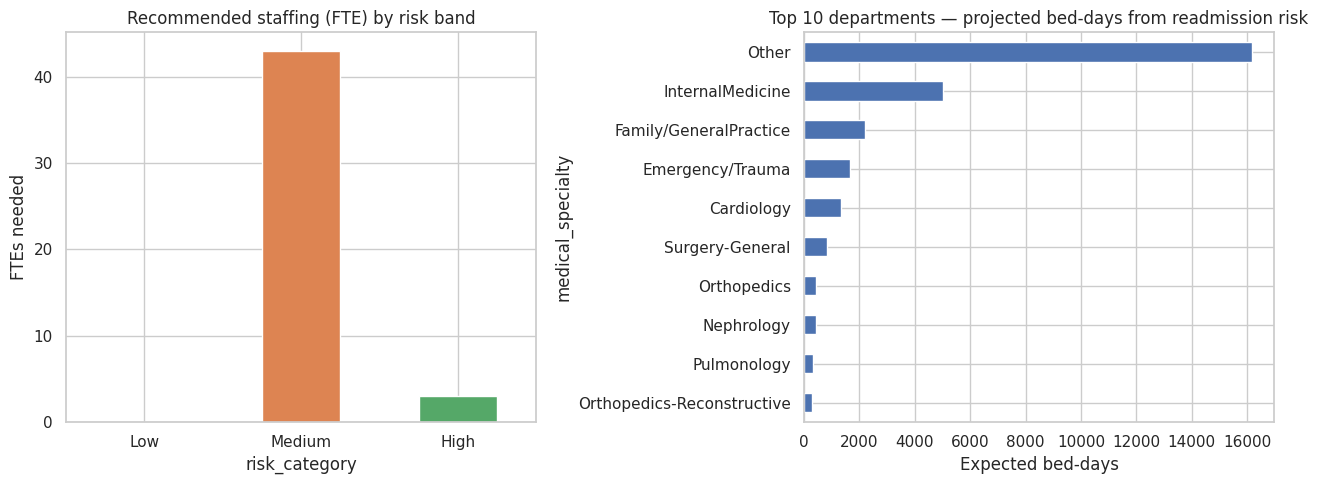

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

resource_plan['recommended_fte'].plot(kind='bar', ax=axes[0], color=['#C44E52', '#DD8452', '#55A868'])
axes[0].set_title('Recommended staffing (FTE) by risk band')
axes[0].set_ylabel('FTEs needed')
axes[0].tick_params(axis='x', rotation=0)

top_dept_bed_days = (dept_plan.reset_index()
                      .groupby('medical_specialty')['expected_bed_days'].sum()
                      .sort_values(ascending=False).head(10))
top_dept_bed_days.plot(kind='barh', ax=axes[1], color='#4C72B0')
axes[1].set_title('Top 10 departments — projected bed-days from readmission risk')
axes[1].set_xlabel('Expected bed-days')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()


### 8.4 Save the resource plan

In [26]:
resource_plan.to_csv('hospital_resource_plan.csv')
dept_plan.to_csv('department_resource_plan.csv')
print("Saved: hospital_resource_plan.csv, department_resource_plan.csv")
resource_plan


Saved: hospital_resource_plan.csv, department_resource_plan.csv


,n_patients,avg_time_in_hospital,avg_num_procedures,avg_num_medications,avg_num_lab_procedures,predicted_readmit_rate,expected_bed_days,avg_daily_beds_needed,intervention,follow_up_within_days,staff_role,concurrent_caseload,recommended_fte
risk_category,,,,,,,,,,,,,
Low,2346,2.81,1.20,12.64,35.13,0.27,1782.1,59.40,Standard discharge instructions,30,None (standard discharge),2346.0,0
Medium,10822,4.48,1.51,16.08,44.15,0.47,23787.3,792.91,Structured follow-up phone call + pharmacist m...,7,Follow-up nurse,2525.1,43
High,830,5.59,1.30,18.11,47.58,0.73,3378.8,112.63,Case-manager led transition-of-care + home hea...,2,Case manager,55.3,3


In [27]:
out.to_csv('test_risk_scores.csv', index=False)

submission = out[['encounter_id', 'predicted_probability', 'risk_category']].reset_index(drop=True)
submission.to_csv('submission.csv', index=False)

# Full pipeline, convenient for reuse in this same notebook/environment.
joblib.dump(best_pipe, 'clinical_readmission_model.joblib')

# Also save the preprocessor and classifier separately, in version-portable formats.
# XGBoost's pickled state is tied to the exact xgboost version that wrote it -- loading it
# with a different xgboost version (e.g. training here vs. running app.py on another machine)
# raises "input stream corrupted". XGBoost's own save_model()/load_model() format is designed
# to be portable across versions, so app.py uses these files instead of the joblib pickle.
joblib.dump(best_pipe.named_steps['pre'], 'preprocessor.joblib')

clf = best_pipe.named_steps['clf']
if hasattr(clf, 'save_model'):  # XGBoost
    clf.save_model('classifier_model.json')
    clf_format = 'xgboost_json'
else:  # LogisticRegression / RandomForest -- plain sklearn objects, pickle fine
    joblib.dump(clf, 'classifier_model.joblib')
    clf_format = 'sklearn_joblib'

import json
with open('model_metadata.json', 'w') as f:
    json.dump({'best_model': best_name, 'classifier_format': clf_format}, f)

print("Saved: test_risk_scores.csv, submission.csv, clinical_readmission_model.joblib,",
      "preprocessor.joblib, classifier_model.*, model_metadata.json")
submission.head()


Saved: test_risk_scores.csv, submission.csv, clinical_readmission_model.joblib, preprocessor.joblib, classifier_model.*, model_metadata.json


,encounter_id,predicted_probability,risk_category
0,96431664,0.308408,Low
1,146293770,0.419749,Medium
2,128884314,0.565594,Medium
3,71578422,0.449478,Medium
4,330778598,0.386652,Medium
